# PROJEKT ZALICZENIOWY - Notebook 1: Dane i przetwarzanie wstępne
## Wykrywanie cyberprzemocy w polskich tweetach (PolEval 2019)

* **Autor:** Dominika Sielawa
* **Opis:**  Projekt realzuje zadanie klsyfikacji tekstu (wykrywanie hejtu/cyberprzemocy). Porównujemy podejście klayczne (TD-IDF + klasyfikator) z podejściem opartym na Transformerach (np. HerBERT).
* **Źródło danych:** Zbiór `ptaszynski/cdt` z Hugging Face Datasets (jest to zaktualizowana i bezpieczna wersja zbioru z polskiego konkursu PolEval 2019). Zbiór zawiera polskojęzyczne tweety z z przypisanymi etykietami.

**W tym notebooku:**
1. Importujemy niezbędne biblioteki.
2. Pobieramy i ładujemy dane.
3. Przeprowadzamy eksploracyjną analizę danych (EDA).
4. Wykonujemy przetwarzanie wstępne tekstu (normalizacja, czyszczenie).
5. Dzielimy dane na zbiory.

### 1. Instalacja i import bibliotek

In [1]:
!pip install datasets pandas numpy matplotlib seaborn scikit-learn spacy
!python -m spacy download pl_core_news_sm

import re
from typing import List, Dict, Any

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Ustawienia wizualne dla wykresów w dalszej części
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Biblioteki zaimportowane pomyślnie!")

'pip' is not recognized as an internal or external command,
operable program or batch file.
The system cannot find the file C:\Users\Domi\AppData\Local\Microsoft\WindowsApps\python.exe.
C:\Users\Domi\PycharmProjects\projekt_169493\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Biblioteki zaimportowane pomyślnie!


### 2. Pobieranie i załadowanie danych

Korzystamy ze zbioru `ptaszynski/cdt` dostępnego na Hugging Face. Zbiór zawiera polskojęzyczne tweety z przypisanymi klasami: 0 (brak cyberprzemocy) oraz 1 (cyberprzemoc).

In [2]:
nlp: spacy.Language = spacy.load('pl_core_news_sm')
dataset = load_dataset("ptaszynski/cdt", split="train")

# Konwersja do DataFrame
df: pd.DataFrame = dataset.to_pandas()

print(f"Liczba rekordów: {len(df)}")
print(f"Kolumny: {list(df.columns)}")


df.head()

Liczba rekordów: 10041
Kolumny: ['sentence', 'target']


,sentence,target
0,Dla mnie faworytem do tytułu będzie Cracovia. ...,0
1,@anonymized_account @anonymized_account Brawo ...,0
2,"@anonymized_account @anonymized_account Super,...",0
3,@anonymized_account @anonymized_account Musi. ...,0
4,"Odrzut natychmiastowy, kwaśna mina, mam problem",0


### 2.1 Weryfikacja i ujednolicenie etykiet

W przeciwieństwie do zbiorów z ocenami w skali 1-5, nasz zbiór posiada już binarne etykiety (0 - brak cyberprzemocy, 1 - cyberprzemoc). W tym kroku upewniamy się, że kolumny mają standardowe nazwy (`text` i `label`) oraz że etykiety są poprawnego typu.

In [4]:
df_binary: pd.DataFrame = df.copy()

# Upewniamy się, że kolumny nazywają się 'text' i 'label'
if 'class' in df_binary.columns:
    df_binary = df_binary.rename(columns={'class': 'label'})
elif 'target' in df_binary.columns:
    df_binary = df_binary.rename(columns={'target': 'label'})

# Wymuszenie typu całkowitoliczbowego dla etykiet (dla pewności)
df_binary['label'] = df_binary['label'].astype(int)

print(f"Liczba rekordów gotowych do analizy: {len(df_binary)}")
print("\nRozkład etykiet (0 - brak hejtu, 1 - hejt):")
print(df_binary["label"].value_counts())

Liczba rekordów gotowych do analizy: 10041

Rozkład etykiet (0 - brak hejtu, 1 - hejt):
label
0    9190
1     851
Name: count, dtype: int64


### 3. Eksploracyjna analiza danych (EDA)

Sprawdzamy rozkład klas w naszym zbiorze binarnym oraz analizujemy długość tekstów (liczbę słów), co będzie kluczowe przy późniejszym doborze parametrów dla modelu Transformer.

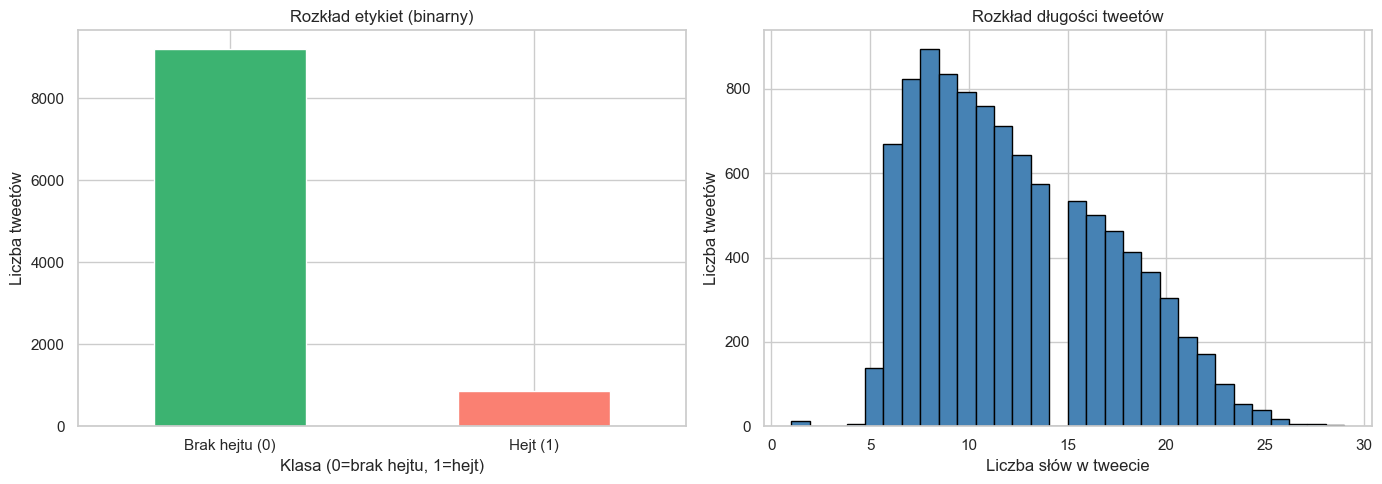

Brakujące wartości w tekście: 0
Brakujące wartości w etykietach: 0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Wykres 1
df_binary["label"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["mediumseagreen", "salmon"]
)
axes[0].set_title("Rozkład etykiet (binarny)")
axes[0].set_xlabel("Klasa (0=brak hejtu, 1=hejt)")
axes[0].set_ylabel("Liczba tweetów")
axes[0].set_xticklabels(["Brak hejtu (0)", "Hejt (1)"], rotation=0)

# Wykres 2
tweet_word_counts = df_binary["sentence"].apply(lambda x: len(str(x).split()))

tweet_word_counts.plot(
    kind="hist", bins=30, ax=axes[1], color="steelblue", edgecolor="black"
)
axes[1].set_title("Rozkład długości tweetów")
axes[1].set_xlabel("Liczba słów w tweecie")
axes[1].set_ylabel("Liczba tweetów")

plt.tight_layout()
plt.show()

print(f"Brakujące wartości w tekście: {df_binary['sentence'].isnull().sum()}")
print(f"Brakujące wartości w etykietach: {df_binary['label'].isnull().sum()}")

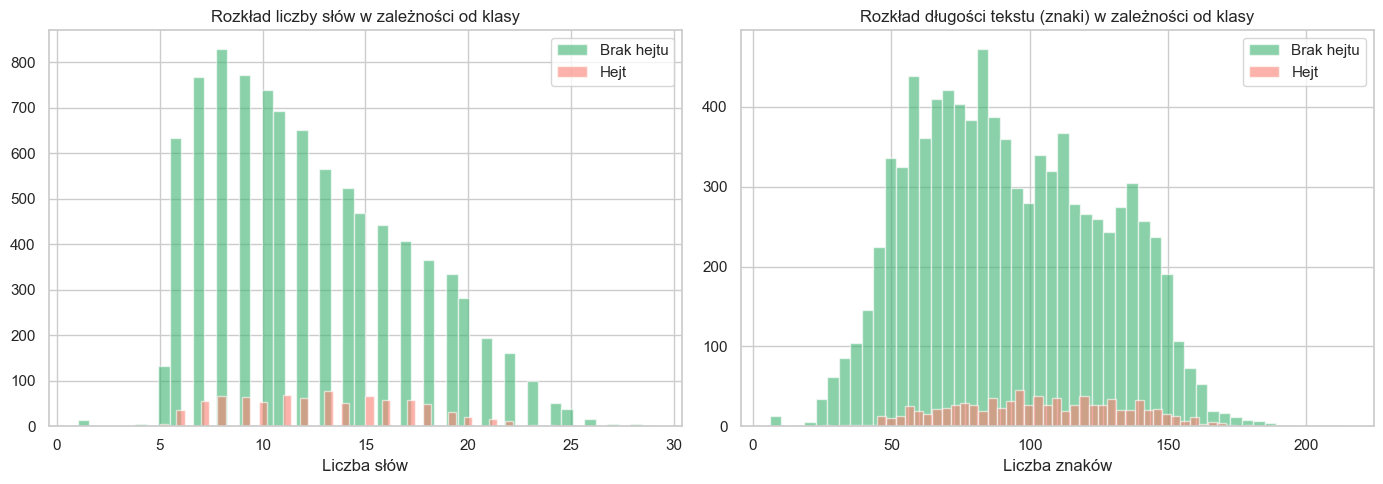

Statystyki długości tweetów (słowa) z podziałem na klasy:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,9190.0,12.327095,4.761852,1.0,8.0,12.0,16.0,29.0
1,851.0,12.857814,4.228446,5.0,9.0,13.0,16.0,25.0


In [6]:
# Obliczanie długości tweetów
df_binary["text_length"] = df_binary["sentence"].astype(str).apply(len)
df_binary["word_count"] = df_binary["sentence"].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Definiujemy klasy
classes_to_plot = [
    (0, "mediumseagreen", "Brak hejtu"),
    (1, "salmon", "Hejt")
]

# Rysowanie wykresów
for label_val, color, label_name in classes_to_plot:
    subset = df_binary[df_binary["label"] == label_val]
    axes[0].hist(subset["word_count"], bins=50, alpha=0.6, label=label_name, color=color)
    axes[1].hist(subset["text_length"], bins=50, alpha=0.6, label=label_name, color=color)

axes[0].set_title("Rozkład liczby słów w zależności od klasy")
axes[0].set_xlabel("Liczba słów")
axes[0].legend()

axes[1].set_title("Rozkład długości tekstu (znaki) w zależności od klasy")
axes[1].set_xlabel("Liczba znaków")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statystyki długości tweetów (słowa) z podziałem na klasy:")
display(df_binary.groupby("label")["word_count"].describe())

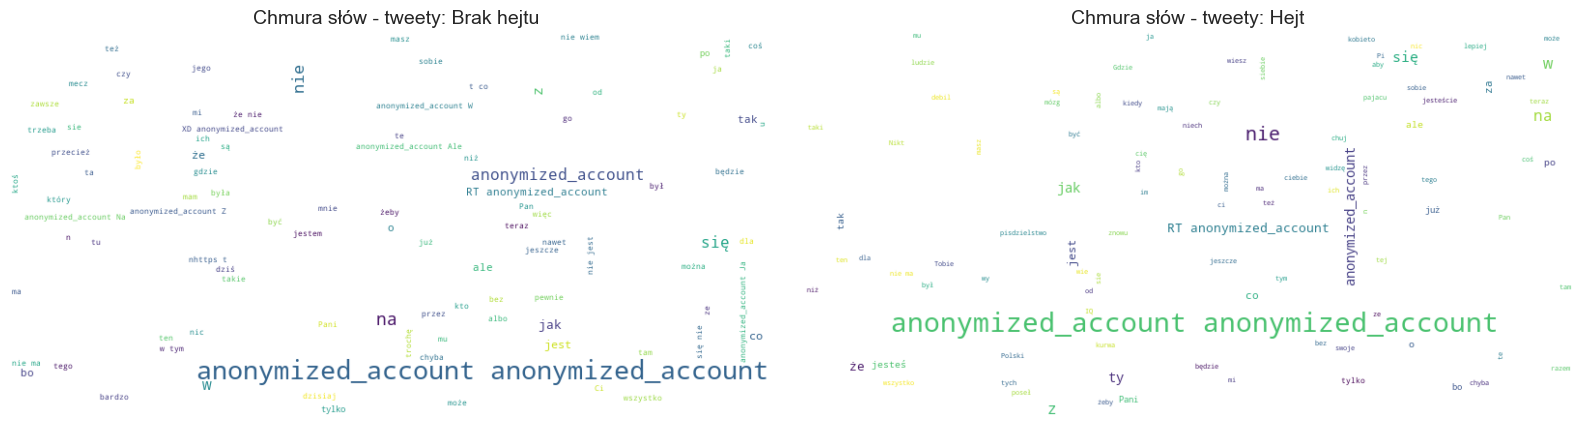

In [7]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

klasy_do_chmury = [(0, "Brak hejtu"), (1, "Hejt")]

for idx, (label_val, title) in enumerate(klasy_do_chmury):

    texts = " ".join(df_binary[df_binary["label"] == label_val]["sentence"].astype(str))

    # Konfiguracja i generowanie chmury słów
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=100
    ).generate(texts)

    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Chmura słów - tweety: {title}", fontsize=14)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

### 4. Przetwarzanie wstępne tekstu

Jak pokazały chmury słów, surowy tekst z Twittera jest pełen szumu: tagów `anonymized_account`, oznaczeń retweetów (`RT`) oraz powszechnych polskich słów (`nie`, `się`, `w`). W tym kroku oczyszczamy dane, przygotowując je pod modele klasyczne:
1. Zamieniamy tekst na małe litery.
2. Usuwamy specyficzne tagi dla tego zbioru (np. `anonymized_account`).
3. Wykonujemy tokenizację i lematyzację przy użyciu biblioteki `spacy`.
4. Usuwamy interpunkcję oraz polskie stop words.

In [ ]:
import re

def clean_text(text: str) -> str:

    # zamiana na małe litery
    text = text.lower()

    # twarde wycięcie tagów z Twittera
    text = re.sub(r'@anonymized_account', '', text)
    text = re.sub(r'\brt\b', '', text)

    doc = nlp(text)

    cleaned_tokens = []
    for token in doc:
        if not token.is_stop and not token.is_punct and not token.is_space:
            cleaned_tokens.append(token.lemma_)

    return " ".join(cleaned_tokens)

print("Rozpoczynam czyszczenie tekstu...")

# Tworzymy nową kolumnę z oczyszczonym tekstem
df_binary["cleaned_text"] = df_binary["sentence"].apply(clean_text)

print("Czyszczenie zakończone!")


display(df_binary[["sentence", "cleaned_text"]].head(10))

In [ ]:
# Usunięcie pustych rekordów po przetworzeniu
df_binary = df_binary[df_binary["cleaned_text"].str.len() > 0].reset_index(drop=True)

print(f"Rekordów gotowych do podziału (po odrzuceniu pustych): {len(df_binary)}")

### 5. Podział na zbiory treningowy, walidacyjny i testowy

In [ ]:
MAX_SAMPLES = 5000

if len(df_binary) > MAX_SAMPLES:
    df_sample = df_binary.sample(n=MAX_SAMPLES, random_state=42).reset_index(drop=True)
    print(f"Losowo wybrano {MAX_SAMPLES} próbek z {len(df_binary)}")
else:
    df_sample = df_binary.copy()
    print(f"Używamy pełnego zbioru: {len(df_sample)} próbek")


train_df, temp_df = train_test_split(
    df_sample, test_size=0.3, random_state=42, stratify=df_sample["label"]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"]
)

print(f"\nRozmiary zbiorów:")
print(f" Treningowy: {len(train_df)}")
print(f" Walidacyjny: {len(val_df)}")
print(f" Testowy: {len(test_df)}")

print(f"\nRozkład klas w zbiorze treningowym (w %):")
print(train_df["label"].value_counts(normalize=True) * 100)

In [ ]:
# Zapis do CSV
train_df.to_csv("train.csv", index=False, encoding='utf-8')
val_df.to_csv("val.csv", index=False, encoding='utf-8')
test_df.to_csv("test.csv", index=False, encoding='utf-8')

print("Dane zapisane pomyślnie do plików: train.csv, val.csv, test.csv")
print("\nKluczowe kolumny w wygenerowanych plikach:")
print(f" 'sentence'     - oryginalny tekst (zostanie użyty przez modele Transformer)")
print(f" 'cleaned_text' - tekst po lematyzacji i usunięciu stopwords (dla podejścia klasycznego)")
print(f" 'label'        - etykieta (0 = brak hejtu, 1 = hejt)")

### Podsumowanie

W tym notebooku:
* Pobraliśmy zbiór polskich tweetów z konkursu PolEval 2019 dotyczący cyberprzemocy (zbiór `ptaszynski/cdt` z Hugging Face).
* Zweryfikowaliśmy binarne etykiety (0 - brak hejtu, 1 - hejt).
* Przeprowadziliśmy eksperymentalną analizę danych (EDA), analizując niezbalansowany rozkład klas, rozkłady długości tweetów oraz chmury słów, które uwidoczniły szum w danych.
* Wykonaliśmy przetwarzanie wstępne tekstu (text preprocessing), w tym lematyzację za pomocą biblioteki `spaCy`, usunięcie interpunkcji, stop words oraz specyficznych tagów (np. `anonymized_account`).
* Ograniczyliśmy wielkość zbioru i podzieliliśmy dane w sposób zbalansowany (stratified split) na zbiór treningowy (70%), walidacyjny (15%) i testowy (15%).
* Zapisaliśmy gotowe, wyczyszczone dane do plików CSV.

Dane są w pełni gotowe do użycia w procesie uczenia modeli w kolejnych notebookach.